In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from IPython.core.pylabtools import figsize


warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [5]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

# Check missing Value

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Check duplicate

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Checking number of unique value of each column

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Exploring data

In [11]:
for column in df.columns:
    print(f"Categories in '{column}' variable   " , end=" ")
    print(df[column].unique())
    print(df[column].value_counts())
    print("-"* 100)

Categories in 'gender' variable    ['female' 'male']
gender
female    518
male      482
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Categories in 'race/ethnicity' variable    ['group B' 'group C' 'group A' 'group D' 'group E']
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Categories in 'parental level of education' variable    ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
-------------------------------------------------------------------------------------------------

In [12]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [13]:
# define numerical and categorical data

numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f"We have {len(numerical_feature)} numerical feature {numerical_feature}")
print(f"We have {len(categorical_feature)} categorical feature {categorical_feature}")

We have 3 numerical feature ['math score', 'reading score', 'writing score']
We have 5 categorical feature ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


# Adding "total score" and "Average"

In [14]:
df["total score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average"]  = df["total score"] / 3

In [15]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df["reading score"] == 100]["average"].count()
writing_full = df[df["writing score"] == 100]["average"].count()
math_full = df[df["math score"] == 100]["average"].count()

print(f"Number of student with full marks in math {math_full}")
print(f"Number of student with full marks in writing {writing_full}")
print(f"Number of student with full reading in math {reading_full}")

Number of student with full marks in math 7
Number of student with full marks in writing 14
Number of student with full reading in math 17


In [17]:
reading_less_20 = df[df["reading score"] <= 20]["average"].count()
writing_less_20 = df[df["writing score"] <= 20]["average"].count()
math_less_20 = df[df["math score"] <= 20]["average"].count()

print(f"Number of student with 20 marks in mat : {math_less_20}")
print(f"Number of student with 20 marks in writing:  {writing_less_20}")
print(f"Number of student with 20 reading in math : {reading_less_20}")

Number of student with 20 marks in mat : 4
Number of student with 20 marks in writing:  3
Number of student with 20 reading in math : 1


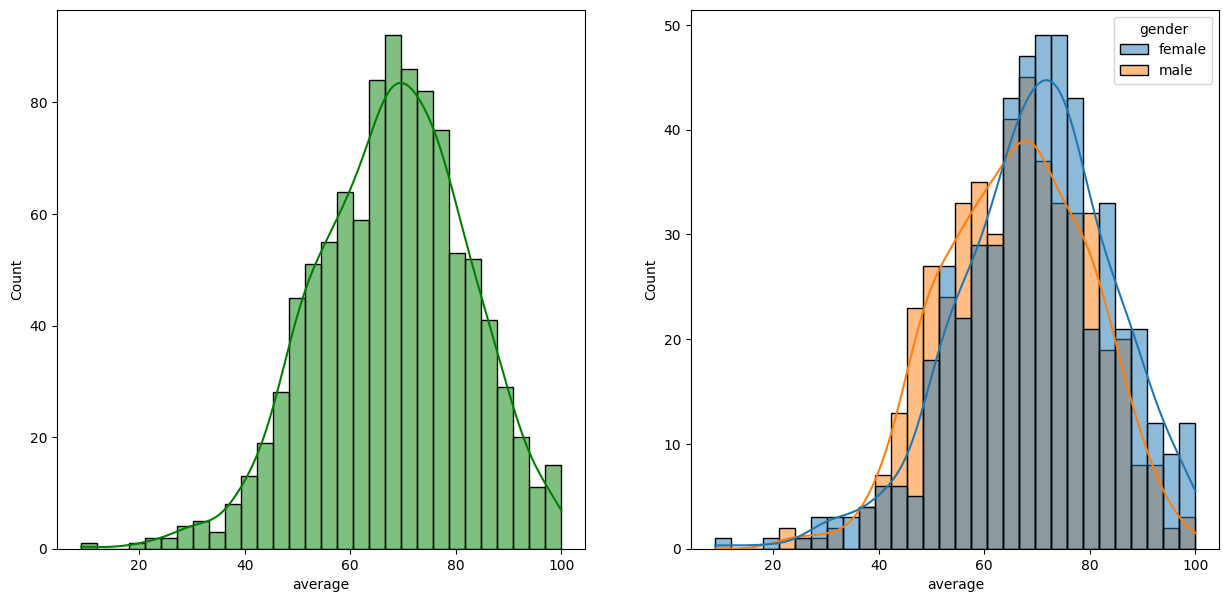

In [18]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x="average", bins=30, kde=True, color="g")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="average", bins=30, kde=True, hue="gender")

plt.show()

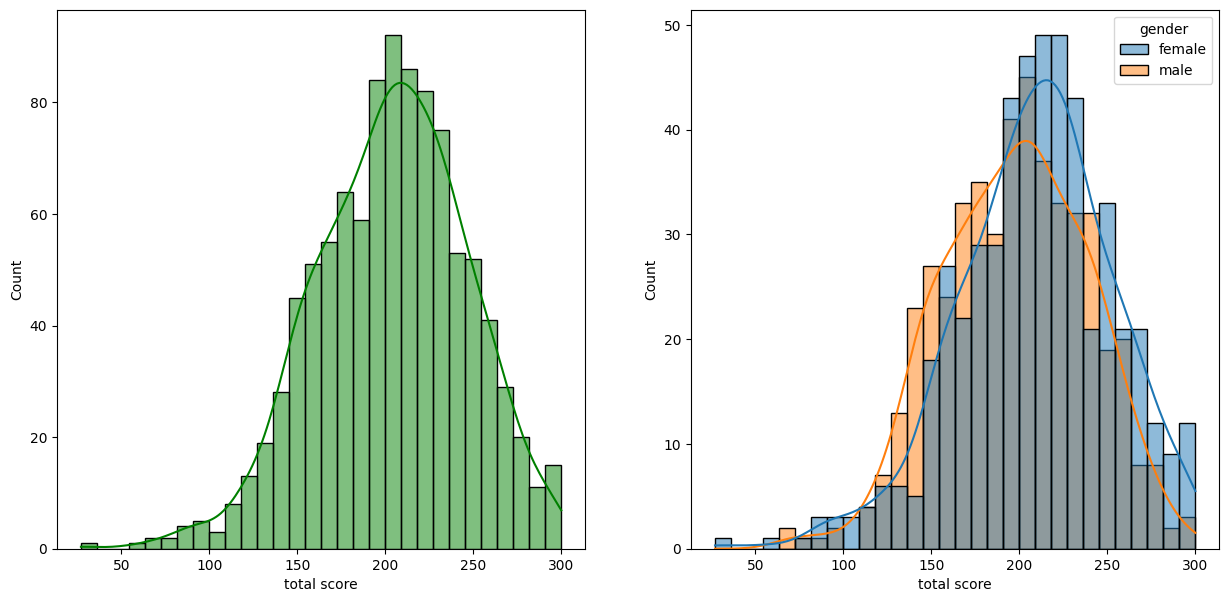

In [19]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x="total score", bins=30, kde=True, color="g")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="total score", bins=30, kde=True, hue="gender")

plt.show()

<Axes: xlabel='average', ylabel='Count'>

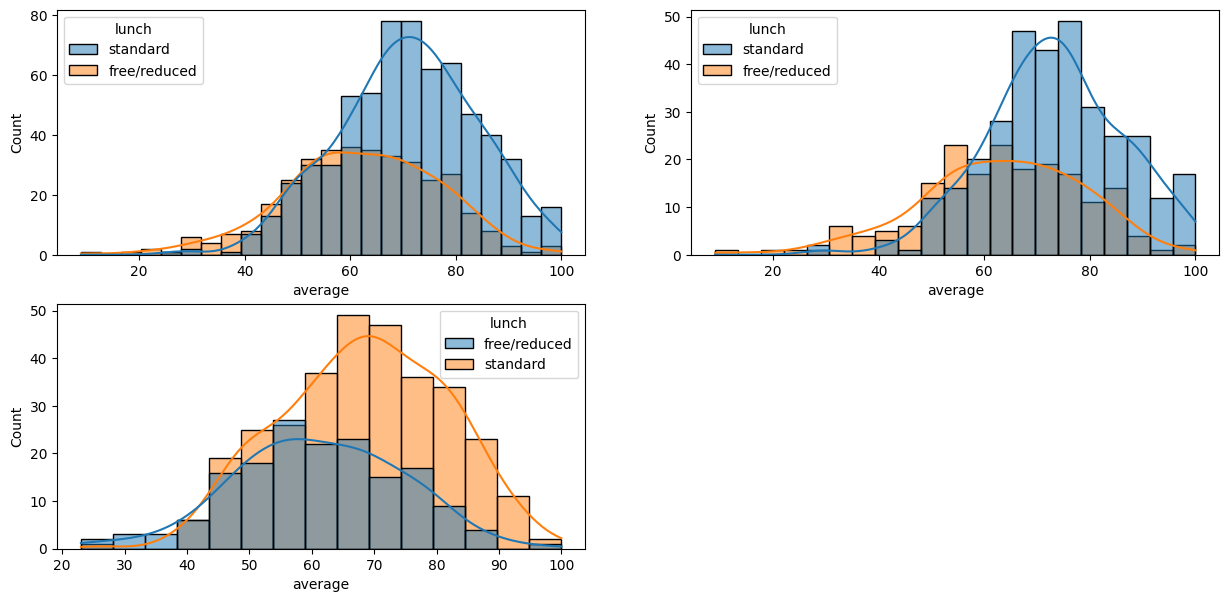

In [20]:
plt.figure(figsize=(15 , 7))

plt.subplot(2 , 2 , 1)
sns.histplot(data=df , x="average" , kde=True , hue="lunch")

plt.subplot(2 , 2 , 2)
sns.histplot(data=df[df.gender == 'female'] , x="average" , kde=True , hue="lunch")

plt.subplot(2 , 2 , 3)
sns.histplot(data=df[df.gender == 'male'] , x="average" , kde=True , hue="lunch")

<Axes: xlabel='average', ylabel='Count'>

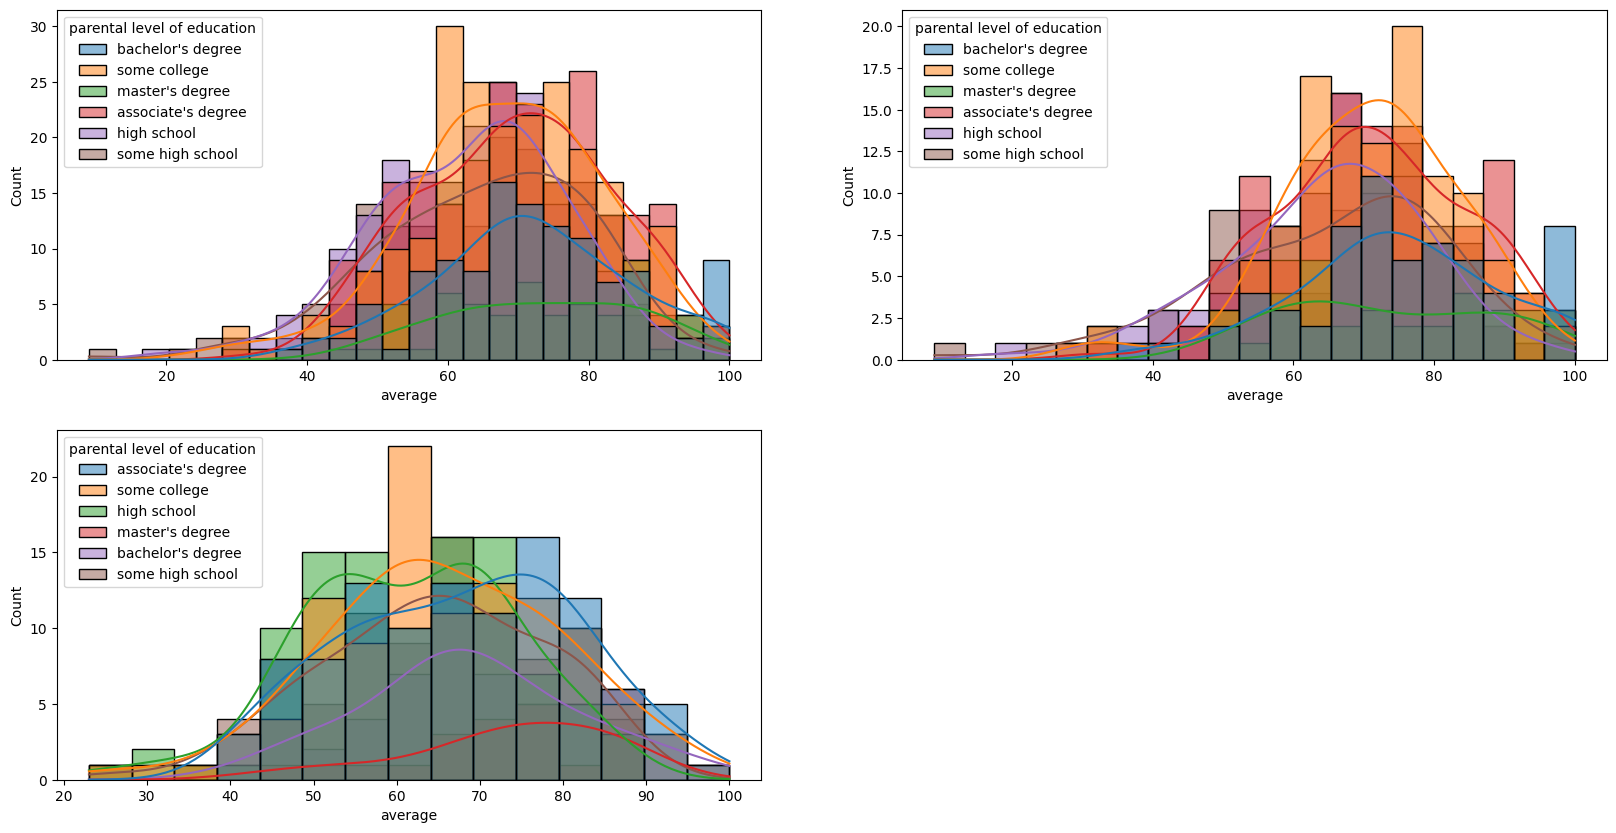

In [21]:
plt.figure(figsize=(20 , 10))

plt.subplot(2 , 2 , 1)
sns.histplot(data=df , x="average" , kde=True , hue="parental level of education")

plt.subplot(2 , 2 , 2)
sns.histplot(data=df[df.gender == 'female'] , x="average" , kde=True , hue="parental level of education")

plt.subplot(2 , 2 , 3)
sns.histplot(data=df[df.gender == 'male'] , x="average" , kde=True , hue="parental level of education")

<Axes: xlabel='average', ylabel='Count'>

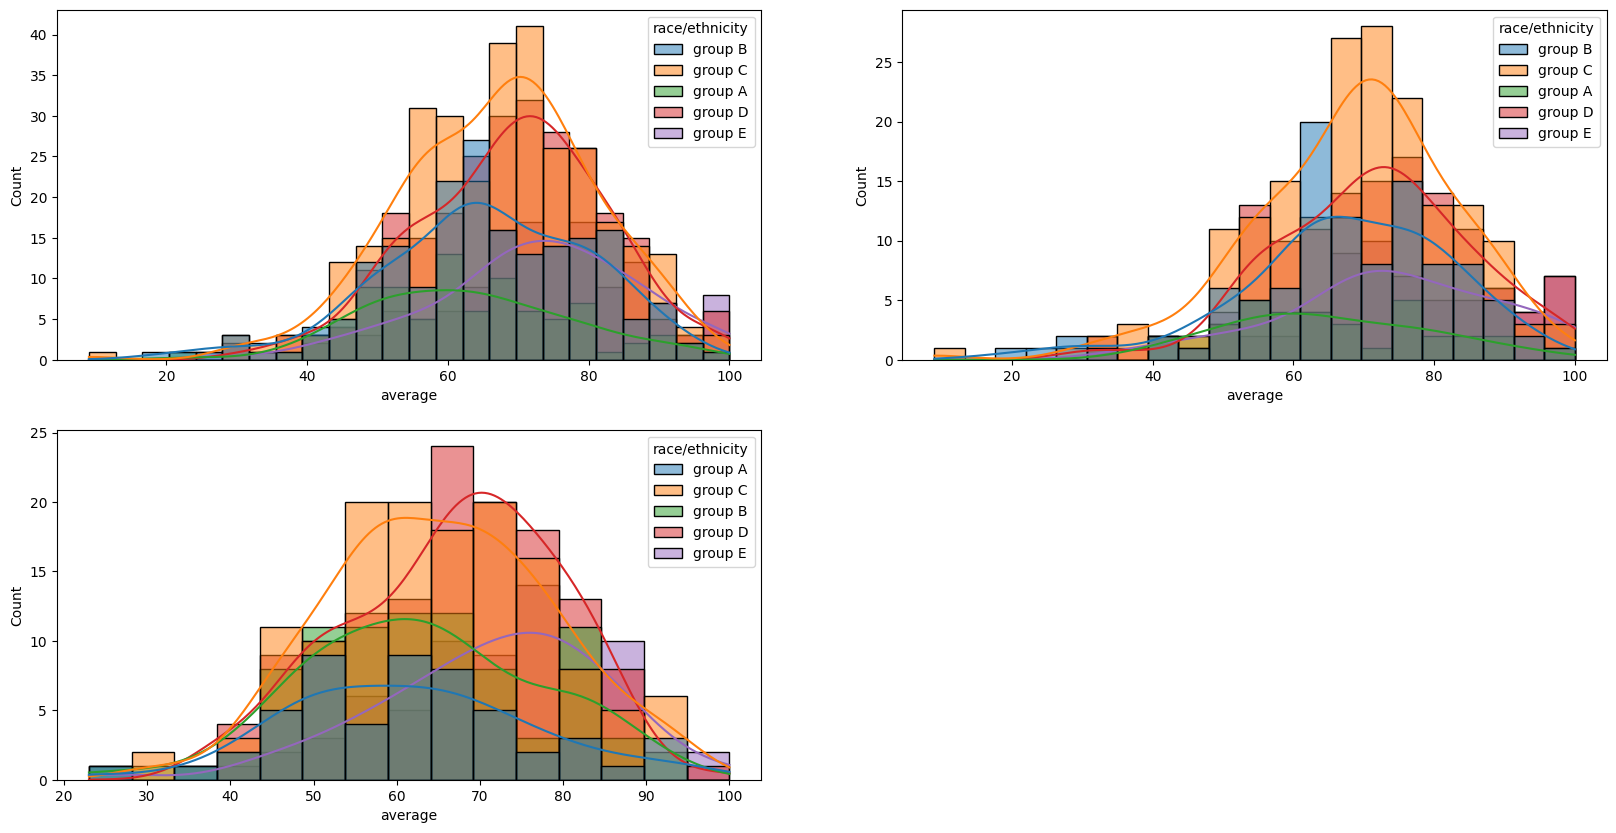

In [22]:
plt.figure(figsize=(20 , 10))

plt.subplot(2 , 2 , 1)
sns.histplot(data=df , x="average" , kde=True , hue="race/ethnicity")

plt.subplot(2 , 2 , 2)
sns.histplot(data=df[df.gender == 'female'] , x="average" , kde=True , hue="race/ethnicity")

plt.subplot(2 , 2 , 3)
sns.histplot(data=df[df.gender == 'male'] , x="average" , kde=True , hue="race/ethnicity")

# Maximum score of students in all three subject

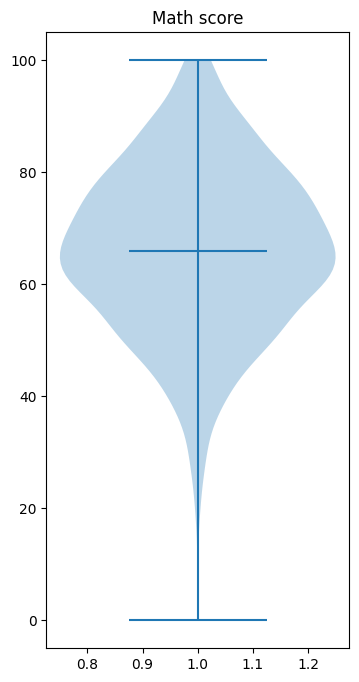

In [23]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 4, 1)
plt.title("Math score")

plt.violinplot(
    df["math score"],
    showmedians=True
)

plt.show()

# Multivarite analysis using pieplot

([<matplotlib.patches.Wedge at 0x320a2f9d0>,
 [Text(0.8341981156790161, 0.717017087521336, 'some college'),
  Text(-0.5717990621018805, 0.939705183863221, "associate's degree"),
  Text(-1.0543739750814827, -0.3135211646298753, 'high school'),
  Text(-0.11383566476996158, -1.0940938905900084, 'some high school'),
  Text(0.8112644257554883, -0.7428660925790179, "bachelor's degree"),
  Text(1.0811581857178525, -0.20272389463327067, "master's degree")],
 [Text(0.45501715400673604, 0.3911002295570923, '22.600000%'),
  Text(-0.31189039751011655, 0.5125664639253932, '22.200000%'),
  Text(-0.5751130773171723, -0.1710115443435683, '19.599999%'),
  Text(-0.062092180783615405, -0.5967784857763682, '17.900001%'),
  Text(0.4425078685939027, -0.40519968686128244, '11.800000%'),
  Text(0.5897226467551923, -0.1105766697999658, '5.900000%')])

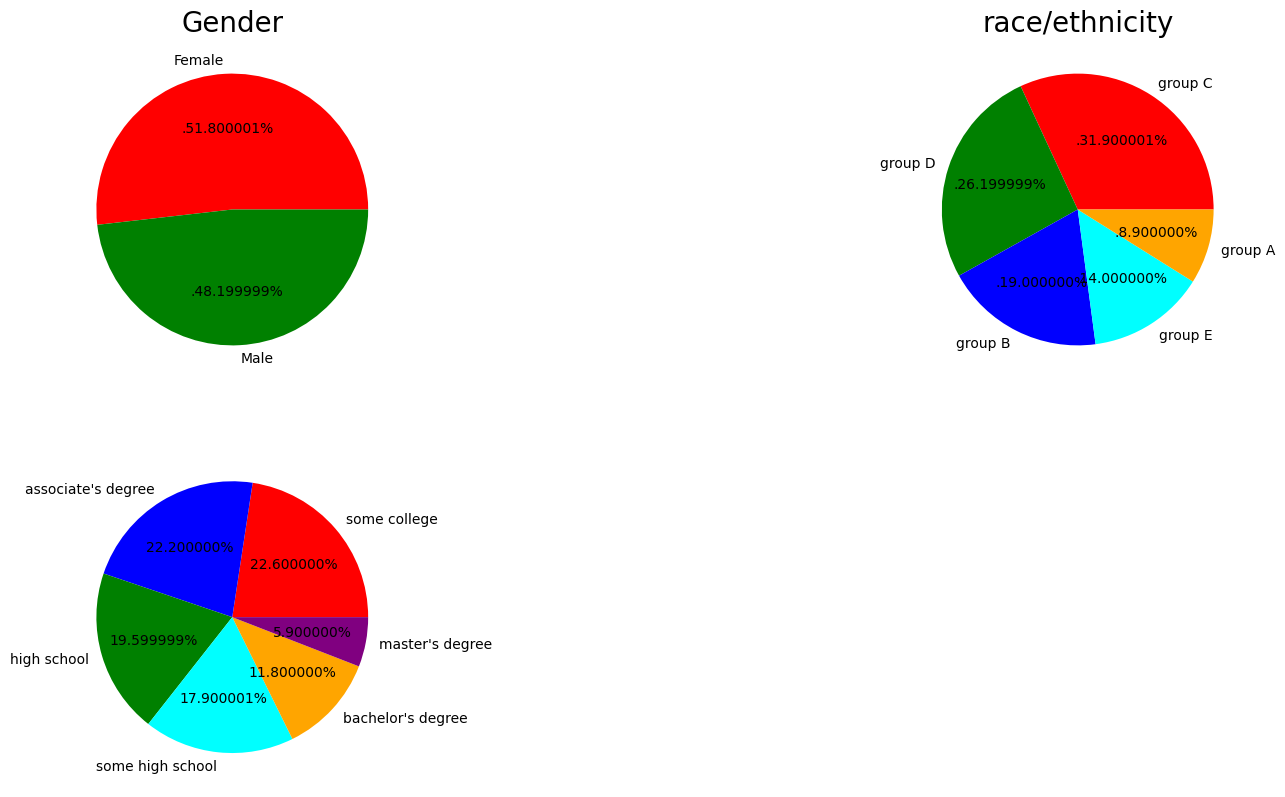

In [37]:
plt.rcParams["figure.figsize"] = (20 , 15)

plt.subplot(3,  2 , 1)
size = df["gender"].value_counts()
label = "Female" , "Male"
color = ["red" , "green"]

plt.pie(size , colors = color , labels = label , autopct=".%2f%%")
plt.title("Gender" , fontsize = 20)
plt.axis("off")


plt.subplot(3,  2 , 2)
size = df["race/ethnicity"].value_counts()
label = "group C " , "group D" ,"group B" ,"group E" ,"group A"

color = ["red" , "green" , "blue" , "cyan" , "orange"]
plt.pie(size , colors = color , labels = label , autopct=".%2f%%")
plt.title("race/ethnicity" , fontsize = 20)
plt.axis("off")


plt.subplot(3 , 2 , 3)
size = df["parental level of education"].value_counts()
label = "some college" , "associate's degree" , "high school" , "some high school" , "bachelor's degree" , "master's degree"
color = ["red" , "blue" , "green" , "cyan" , "orange" , "purple"]
plt.pie(size , colors = color , labels=label , autopct="%2f%%")






In [31]:
df["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [29]:
df["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

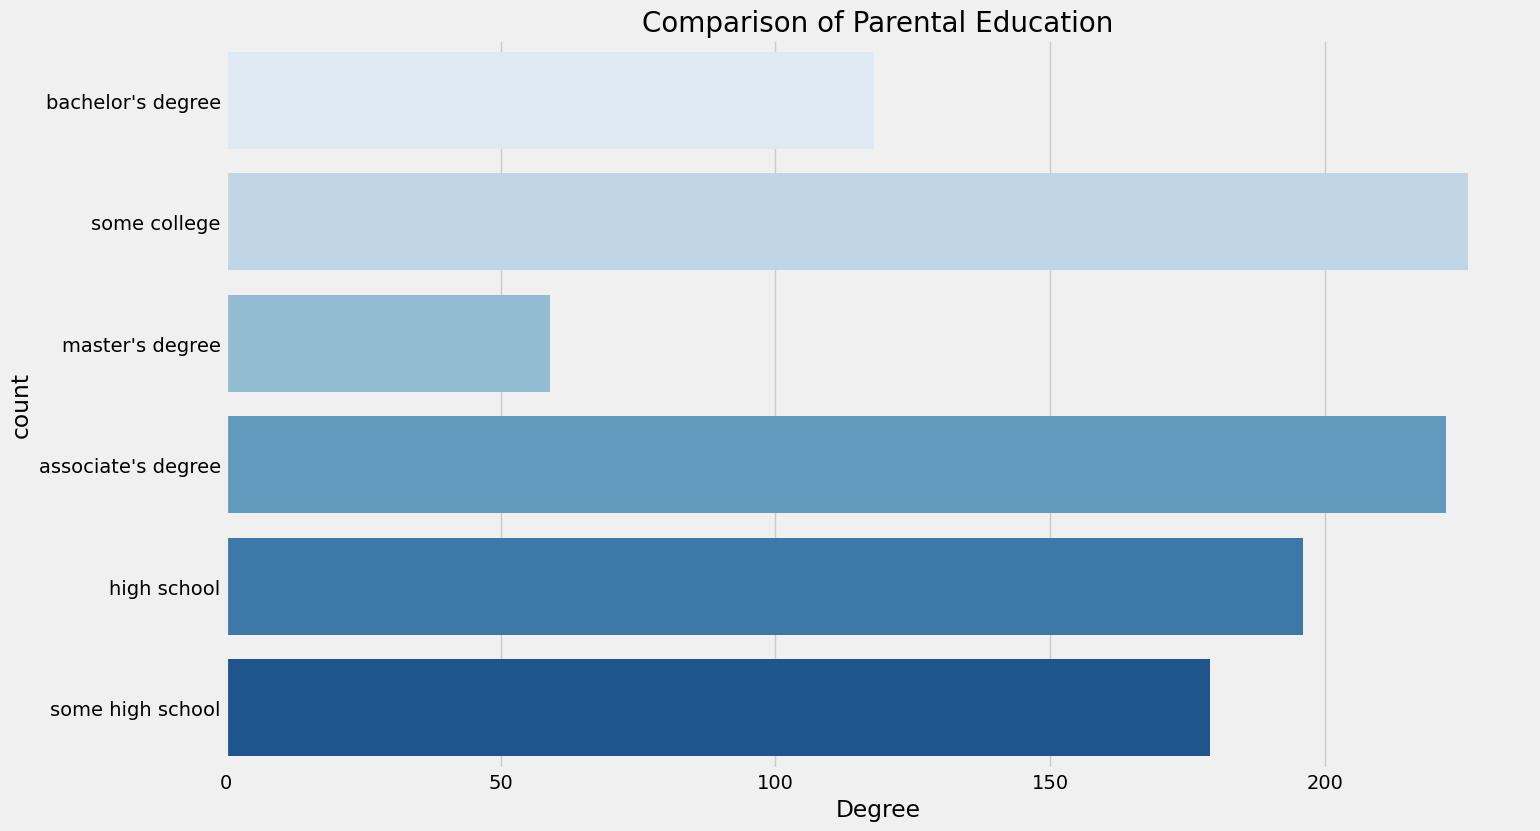

In [38]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

([<matplotlib.patches.Wedge at 0x321049220>,
 [Text(-0.06217041096298424, 1.0982417038160106, 'Male'),
  Text(0.06782226650507357, -1.1980818587083752, 'Female')],
 [Text(-0.033911133252536856, 0.5990409293541875, '51.8%'),
  Text(0.03956298879462625, -0.698881084246552, '48.2%')])

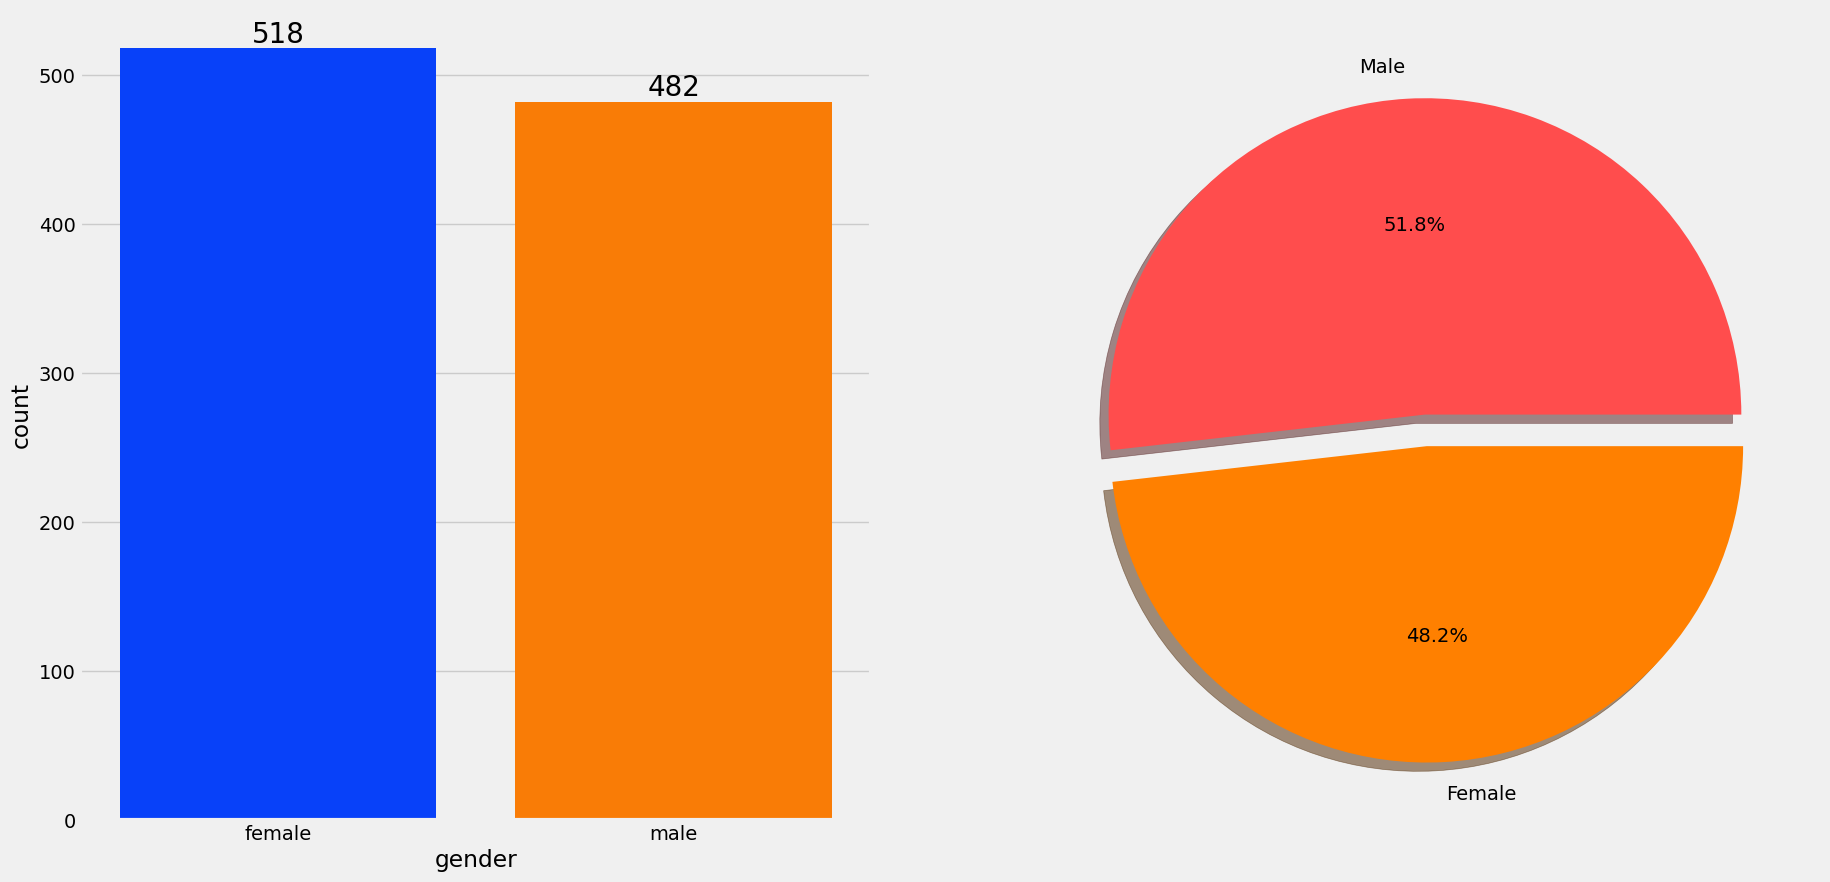

In [42]:
f , ax = plt.subplots(1 , 2 , figsize = (20 , 10))

sns.countplot(
    x = df["gender"] ,
    data=df ,
    palette="bright" ,
    ax = ax[0] ,
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container , color="black" , size=20)

ax[1].pie(
    x = df["gender"].value_counts() ,
    labels = ["Male" , "Female"] ,
    explode=[0 , 0.1] ,
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000']
)

In [44]:
gender_group = df.groupby("gender").mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


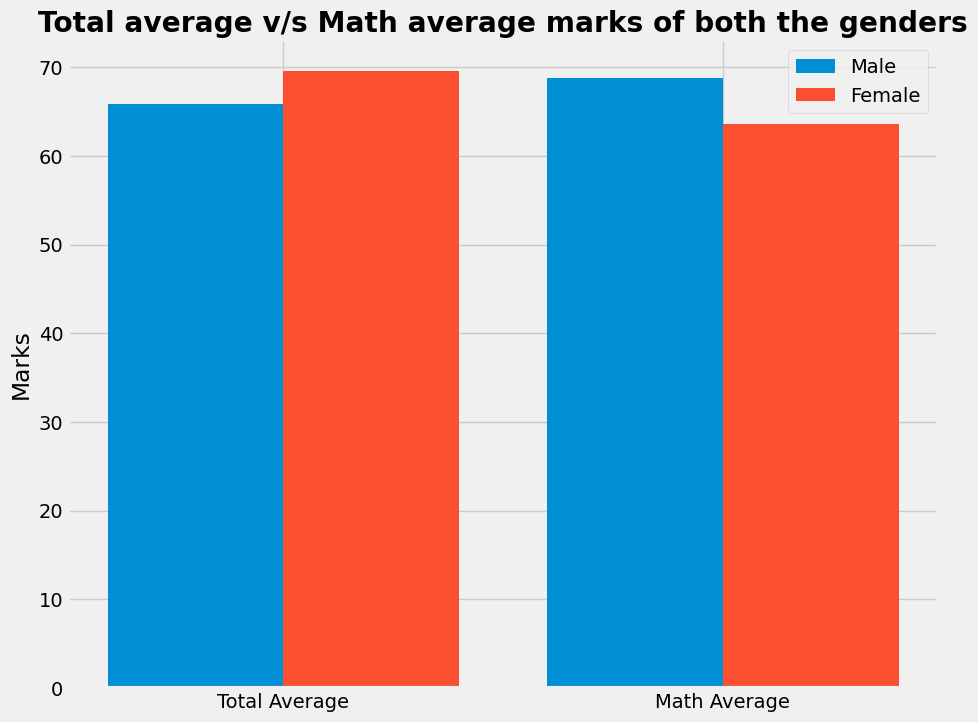

In [48]:
plt.figure(figsize=(10 , 8))

X = ["Total Average" , "Math Average"]

female_scores = [gender_group["average"][0] , gender_group["math score"][0]]
male_scores = [gender_group["average"][1] , gender_group["math score"][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()